In [7]:
def get_obj_values(run_gen_text_content: str):
    output_list = []
    for solution_text in run_gen_text_content.split("--------------")[:-1]:
        run_gen_solution_text_content = solution_text
        output_list.append([float(item[item.find(': ')+2:]) for item in run_gen_solution_text_content[run_gen_solution_text_content.find(']')+1:].split('\n')[1:-1]])
    return output_list

In [8]:
import os

def load_runs_and_gens_as_dict(directory="."):
    data = {}
    run_index = 0

    while True:
        run_key = f"run_{run_index}"
        gen_index = 0
        run_data = []

        while True:
            filename = f"{run_key}_gen_{gen_index}.txt"
            filepath = os.path.join(directory, filename)

            if os.path.isfile(filepath):
                with open(filepath, 'r', encoding='utf-8') as f:
                    run_data.append(get_obj_values(f.read()))
                gen_index += 1
            else:
                break  # No more gens for this run

        if run_data:
            data[run_key] = run_data
            run_index += 1
        else:
            break  # No more runs

    return data


In [9]:
run_gen_dict = load_runs_and_gens_as_dict()
run_gen_dict

{'run_0': [[[0.5, 0.23, 0.74],
   [0.57, 0.25, 0.69],
   [0.49, 0.27, 0.83],
   [0.67, 0.08, 0.75],
   [0.56, 0.19, 0.75],
   [0.54, 0.12, 0.79]],
  [[0.67, 0.08, 0.75],
   [0.56, 0.19, 0.75],
   [0.54, 0.12, 0.79],
   [0.5, 0.22, 0.67],
   [0.47, 0.27, 0.78],
   [0.54, 0.18, 0.78],
   [0.45, 0.3, 0.79]],
  [[0.67, 0.08, 0.75],
   [0.56, 0.19, 0.75],
   [0.54, 0.12, 0.79],
   [0.5, 0.22, 0.67],
   [0.54, 0.18, 0.78],
   [0.47, 0.22, 0.73],
   [0.5, 0.16, 0.81],
   [0.6, 0.18, 0.75],
   [0.59, 0.11, 0.8],
   [0.63, 0.27, 0.66],
   [0.43, 0.27, 0.78],
   [0.62, 0.13, 0.77],
   [0.56, 0.16, 0.77],
   [0.53, 0.21, 0.71]],
  [[0.67, 0.08, 0.75],
   [0.54, 0.12, 0.79],
   [0.5, 0.22, 0.67],
   [0.47, 0.22, 0.73],
   [0.5, 0.16, 0.81],
   [0.59, 0.11, 0.8],
   [0.63, 0.27, 0.66],
   [0.43, 0.27, 0.78],
   [0.62, 0.13, 0.77],
   [0.56, 0.16, 0.77],
   [0.43, 0.2, 0.8],
   [0.53, 0.17, 0.73],
   [0.68, 0.08, 0.73],
   [0.48, 0.18, 0.69],
   [0.57, 0.09, 0.89],
   [0.42, 0.26, 0.8]],
  [[0.67, 0

In [10]:
def dict_to_data_for_visualization(run_gen_values_dict: dict):
    all = {}
    for key,run in run_gen_values_dict.items():
        all[key] = {}
        for generation in run:
            all[key][run.index(generation)] = {}
            min_obj1 = min([solution[0] for solution in generation])
            min_obj2 = min([solution[1] for solution in generation])
            min_obj3 = min([solution[2] for solution in generation])
            avg_obj1 = sum([solution[0] for solution in generation]) / len(generation)
            avg_obj2 = sum([solution[1] for solution in generation]) / len(generation)
            avg_obj3 = sum([solution[2] for solution in generation]) / len(generation)

            all[key][run.index(generation)]["min_obj1"] = min_obj1
            all[key][run.index(generation)]["min_obj2"] = min_obj2
            all[key][run.index(generation)]["min_obj3"] = min_obj3

            all[key][run.index(generation)]["avg_obj1"] = avg_obj1
            all[key][run.index(generation)]["avg_obj2"] = avg_obj2
            all[key][run.index(generation)]["avg_obj3"] = avg_obj3

            print(f"For the run index {key} and generation index {run.index(generation)}:")
            print(f"MIN of objective index 0: {min_obj1}")
            print(f"MIN of objective index 1: {min_obj2}")
            print(f"MIN of objective index 2: {min_obj3}")
            print(f"AVG of objective index 0: {avg_obj1}")
            print(f"AVG of objective index 1: {avg_obj2}")
            print(f"AVG of objective index 2: {avg_obj3}")
            print("--------------")
    return all


visualization_data = dict_to_data_for_visualization(run_gen_dict)
visualization_data

For the run index run_0 and generation index 0:
MIN of objective index 0: 0.49
MIN of objective index 1: 0.08
MIN of objective index 2: 0.69
AVG of objective index 0: 0.555
AVG of objective index 1: 0.19000000000000003
AVG of objective index 2: 0.7583333333333333
--------------
For the run index run_0 and generation index 1:
MIN of objective index 0: 0.45
MIN of objective index 1: 0.08
MIN of objective index 2: 0.67
AVG of objective index 0: 0.5328571428571428
AVG of objective index 1: 0.1942857142857143
AVG of objective index 2: 0.7585714285714287
--------------
For the run index run_0 and generation index 2:
MIN of objective index 0: 0.43
MIN of objective index 1: 0.08
MIN of objective index 2: 0.66
AVG of objective index 0: 0.5528571428571428
AVG of objective index 1: 0.17857142857142858
AVG of objective index 2: 0.7514285714285714
--------------
For the run index run_0 and generation index 3:
MIN of objective index 0: 0.42
MIN of objective index 1: 0.08
MIN of objective index 2: 0.

{'run_0': {0: {'min_obj1': 0.49,
   'min_obj2': 0.08,
   'min_obj3': 0.69,
   'avg_obj1': 0.555,
   'avg_obj2': 0.19000000000000003,
   'avg_obj3': 0.7583333333333333},
  1: {'min_obj1': 0.45,
   'min_obj2': 0.08,
   'min_obj3': 0.67,
   'avg_obj1': 0.5328571428571428,
   'avg_obj2': 0.1942857142857143,
   'avg_obj3': 0.7585714285714287},
  2: {'min_obj1': 0.43,
   'min_obj2': 0.08,
   'min_obj3': 0.66,
   'avg_obj1': 0.5528571428571428,
   'avg_obj2': 0.17857142857142858,
   'avg_obj3': 0.7514285714285714},
  3: {'min_obj1': 0.42,
   'min_obj2': 0.08,
   'min_obj3': 0.66,
   'avg_obj1': 0.53875,
   'avg_obj2': 0.17,
   'avg_obj3': 0.760625},
  4: {'min_obj1': 0.4,
   'min_obj2': 0.08,
   'min_obj3': 0.66,
   'avg_obj1': 0.5255555555555556,
   'avg_obj2': 0.175,
   'avg_obj3': 0.7616666666666667},
  5: {'min_obj1': 0.33,
   'min_obj2': 0.1,
   'min_obj3': 0.57,
   'avg_obj1': 0.5157894736842106,
   'avg_obj2': 0.23842105263157895,
   'avg_obj3': 0.6947368421052631},
  6: {'min_obj1': 0

{0: {'min_obj1': 0.49, 'min_obj2': 0.08, 'min_obj3': 0.69, 'avg_obj1': 0.555, 'avg_obj2': 0.19000000000000003, 'avg_obj3': 0.7583333333333333}, 1: {'min_obj1': 0.45, 'min_obj2': 0.08, 'min_obj3': 0.67, 'avg_obj1': 0.5328571428571428, 'avg_obj2': 0.1942857142857143, 'avg_obj3': 0.7585714285714287}, 2: {'min_obj1': 0.43, 'min_obj2': 0.08, 'min_obj3': 0.66, 'avg_obj1': 0.5528571428571428, 'avg_obj2': 0.17857142857142858, 'avg_obj3': 0.7514285714285714}, 3: {'min_obj1': 0.42, 'min_obj2': 0.08, 'min_obj3': 0.66, 'avg_obj1': 0.53875, 'avg_obj2': 0.17, 'avg_obj3': 0.760625}, 4: {'min_obj1': 0.4, 'min_obj2': 0.08, 'min_obj3': 0.66, 'avg_obj1': 0.5255555555555556, 'avg_obj2': 0.175, 'avg_obj3': 0.7616666666666667}, 5: {'min_obj1': 0.33, 'min_obj2': 0.1, 'min_obj3': 0.57, 'avg_obj1': 0.5157894736842106, 'avg_obj2': 0.23842105263157895, 'avg_obj3': 0.6947368421052631}, 6: {'min_obj1': 0.31, 'min_obj2': 0.1, 'min_obj3': 0.57, 'avg_obj1': 0.5171428571428571, 'avg_obj2': 0.22333333333333336, 'avg_ob

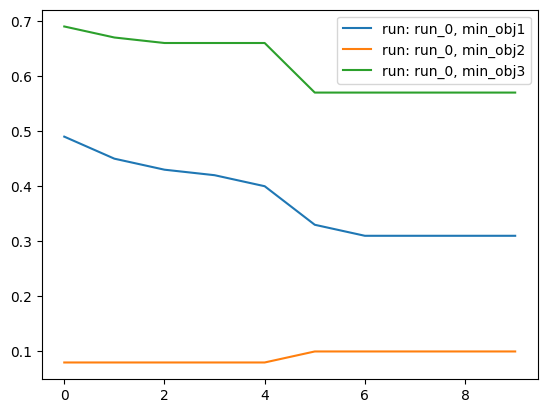

{0: {'min_obj1': 0.52, 'min_obj2': 0.25, 'min_obj3': 0.6, 'avg_obj1': 0.5641666666666667, 'avg_obj2': 0.345, 'avg_obj3': 0.7566666666666667}, 1: {'min_obj1': 0.48, 'min_obj2': 0.25, 'min_obj3': 0.6, 'avg_obj1': 0.5481818181818182, 'avg_obj2': 0.3181818181818182, 'avg_obj3': 0.7663636363636364}, 2: {'min_obj1': 0.46, 'min_obj2': 0.2, 'min_obj3': 0.59, 'avg_obj1': 0.5436842105263158, 'avg_obj2': 0.33, 'avg_obj3': 0.7273684210526316}, 3: {'min_obj1': 0.46, 'min_obj2': 0.2, 'min_obj3': 0.58, 'avg_obj1': 0.5499999999999999, 'avg_obj2': 0.3204166666666667, 'avg_obj3': 0.7229166666666668}, 4: {'min_obj1': 0.42, 'min_obj2': 0.2, 'min_obj3': 0.58, 'avg_obj1': 0.5579310344827586, 'avg_obj2': 0.3020689655172414, 'avg_obj3': 0.7241379310344828}, 5: {'min_obj1': 0.42, 'min_obj2': 0.25, 'min_obj3': 0.52, 'avg_obj1': 0.492, 'avg_obj2': 0.381, 'avg_obj3': 0.6295}, 6: {'min_obj1': 0.41, 'min_obj2': 0.24, 'min_obj3': 0.52, 'avg_obj1': 0.4932142857142857, 'avg_obj2': 0.3675, 'avg_obj3': 0.644642857142857

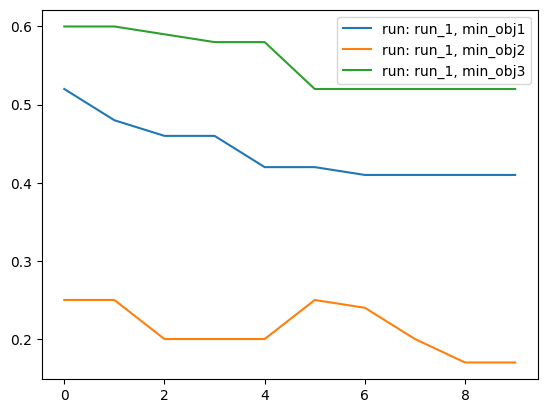

{0: {'min_obj1': 0.52, 'min_obj2': 0.3, 'min_obj3': 0.6, 'avg_obj1': 0.595, 'avg_obj2': 0.34299999999999997, 'avg_obj3': 0.71}, 1: {'min_obj1': 0.52, 'min_obj2': 0.26, 'min_obj3': 0.53, 'avg_obj1': 0.5881818181818181, 'avg_obj2': 0.3427272727272727, 'avg_obj3': 0.6763636363636363}, 2: {'min_obj1': 0.51, 'min_obj2': 0.26, 'min_obj3': 0.53, 'avg_obj1': 0.5833333333333334, 'avg_obj2': 0.335, 'avg_obj3': 0.7055555555555555}, 3: {'min_obj1': 0.5, 'min_obj2': 0.23, 'min_obj3': 0.53, 'avg_obj1': 0.59, 'avg_obj2': 0.3315384615384615, 'avg_obj3': 0.7138461538461538}, 4: {'min_obj1': 0.5, 'min_obj2': 0.23, 'min_obj3': 0.53, 'avg_obj1': 0.5756521739130435, 'avg_obj2': 0.34478260869565214, 'avg_obj3': 0.6726086956521738}, 5: {'min_obj1': 0.42, 'min_obj2': 0.25, 'min_obj3': 0.51, 'avg_obj1': 0.5313636363636364, 'avg_obj2': 0.41318181818181815, 'avg_obj3': 0.6168181818181818}, 6: {'min_obj1': 0.39, 'min_obj2': 0.25, 'min_obj3': 0.51, 'avg_obj1': 0.4988461538461539, 'avg_obj2': 0.40538461538461534, '

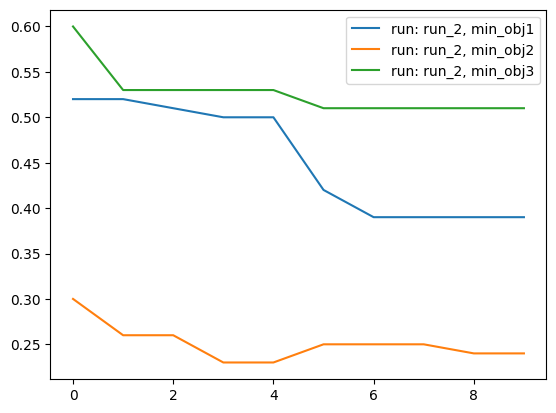

{0: {'min_obj1': 0.52, 'min_obj2': 0.37, 'min_obj3': 0.55, 'avg_obj1': 0.5854545454545454, 'avg_obj2': 0.41545454545454547, 'avg_obj3': 0.6218181818181818}, 1: {'min_obj1': 0.49, 'min_obj2': 0.34, 'min_obj3': 0.55, 'avg_obj1': 0.5786666666666667, 'avg_obj2': 0.41600000000000004, 'avg_obj3': 0.656}, 2: {'min_obj1': 0.45, 'min_obj2': 0.34, 'min_obj3': 0.52, 'avg_obj1': 0.5688888888888889, 'avg_obj2': 0.41444444444444445, 'avg_obj3': 0.6455555555555555}, 3: {'min_obj1': 0.45, 'min_obj2': 0.34, 'min_obj3': 0.52, 'avg_obj1': 0.5673684210526315, 'avg_obj2': 0.40842105263157896, 'avg_obj3': 0.6273684210526316}, 4: {'min_obj1': 0.43, 'min_obj2': 0.32, 'min_obj3': 0.52, 'avg_obj1': 0.5652380952380953, 'avg_obj2': 0.39809523809523806, 'avg_obj3': 0.6333333333333334}, 5: {'min_obj1': 0.46, 'min_obj2': 0.26, 'min_obj3': 0.49, 'avg_obj1': 0.5751724137931035, 'avg_obj2': 0.3903448275862069, 'avg_obj3': 0.5724137931034483}, 6: {'min_obj1': 0.44, 'min_obj2': 0.21, 'min_obj3': 0.49, 'avg_obj1': 0.56600

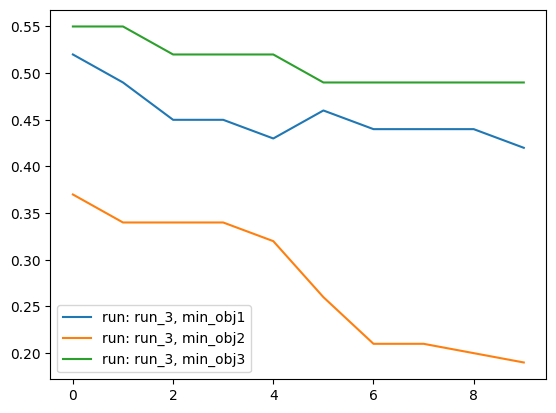

{0: {'min_obj1': 0.52, 'min_obj2': 0.17, 'min_obj3': 0.55, 'avg_obj1': 0.6025, 'avg_obj2': 0.33, 'avg_obj3': 0.63}, 1: {'min_obj1': 0.5, 'min_obj2': 0.17, 'min_obj3': 0.55, 'avg_obj1': 0.59, 'avg_obj2': 0.31272727272727274, 'avg_obj3': 0.6790909090909091}, 2: {'min_obj1': 0.5, 'min_obj2': 0.17, 'min_obj3': 0.52, 'avg_obj1': 0.5933333333333334, 'avg_obj2': 0.3253333333333333, 'avg_obj3': 0.6726666666666666}, 3: {'min_obj1': 0.49, 'min_obj2': 0.17, 'min_obj3': 0.5, 'avg_obj1': 0.5583333333333333, 'avg_obj2': 0.32916666666666666, 'avg_obj3': 0.6491666666666667}, 4: {'min_obj1': 0.49, 'min_obj2': 0.17, 'min_obj3': 0.5, 'avg_obj1': 0.556875, 'avg_obj2': 0.315625, 'avg_obj3': 0.64375}, 5: {'min_obj1': 0.55, 'min_obj2': 0.16, 'min_obj3': 0.44, 'avg_obj1': 0.6121428571428572, 'avg_obj2': 0.28928571428571426, 'avg_obj3': 0.5375}, 6: {'min_obj1': 0.55, 'min_obj2': 0.14, 'min_obj3': 0.44, 'avg_obj1': 0.6123333333333334, 'avg_obj2': 0.2803333333333333, 'avg_obj3': 0.5396666666666667}, 7: {'min_obj

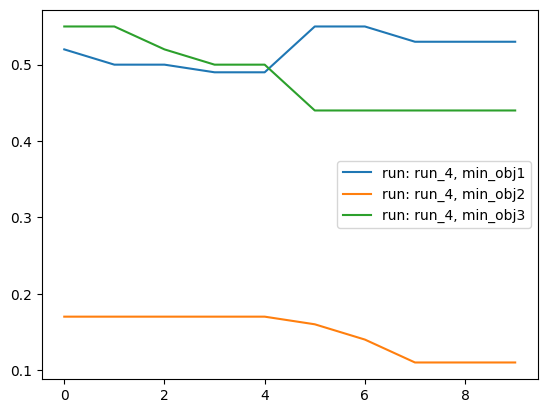

{0: {'min_obj1': 0.49, 'min_obj2': 0.44, 'min_obj3': 0.51, 'avg_obj1': 0.5922222222222222, 'avg_obj2': 0.5144444444444445, 'avg_obj3': 0.5644444444444444}, 1: {'min_obj1': 0.46, 'min_obj2': 0.37, 'min_obj3': 0.49, 'avg_obj1': 0.5823076923076923, 'avg_obj2': 0.5184615384615385, 'avg_obj3': 0.5700000000000001}, 2: {'min_obj1': 0.45, 'min_obj2': 0.37, 'min_obj3': 0.45, 'avg_obj1': 0.5725, 'avg_obj2': 0.5189999999999999, 'avg_obj3': 0.5635}, 3: {'min_obj1': 0.45, 'min_obj2': 0.37, 'min_obj3': 0.45, 'avg_obj1': 0.5789473684210527, 'avg_obj2': 0.5026315789473684, 'avg_obj3': 0.5615789473684211}, 4: {'min_obj1': 0.45, 'min_obj2': 0.33, 'min_obj3': 0.45, 'avg_obj1': 0.5778260869565218, 'avg_obj2': 0.4991304347826087, 'avg_obj3': 0.5930434782608696}, 5: {'min_obj1': 0.44, 'min_obj2': 0.11, 'min_obj3': 0.48, 'avg_obj1': 0.5666666666666667, 'avg_obj2': 0.24125, 'avg_obj3': 0.5541666666666667}, 6: {'min_obj1': 0.42, 'min_obj2': 0.11, 'min_obj3': 0.48, 'avg_obj1': 0.5499999999999999, 'avg_obj2': 0.

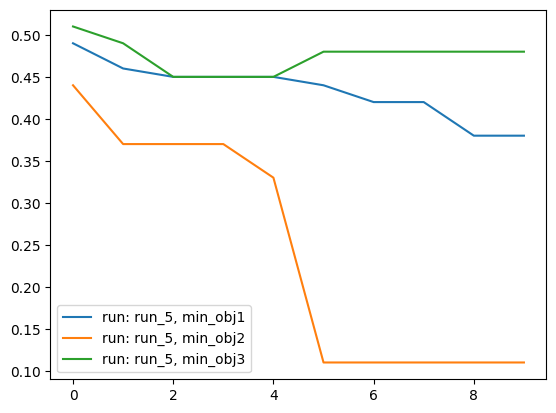

{0: {'min_obj1': 0.55, 'min_obj2': 0.29, 'min_obj3': 0.42, 'avg_obj1': 0.5933333333333334, 'avg_obj2': 0.35833333333333334, 'avg_obj3': 0.535}, 1: {'min_obj1': 0.53, 'min_obj2': 0.29, 'min_obj3': 0.42, 'avg_obj1': 0.5733333333333334, 'avg_obj2': 0.3666666666666667, 'avg_obj3': 0.5783333333333334}, 2: {'min_obj1': 0.53, 'min_obj2': 0.29, 'min_obj3': 0.42, 'avg_obj1': 0.5763636363636363, 'avg_obj2': 0.3836363636363636, 'avg_obj3': 0.6109090909090908}, 3: {'min_obj1': 0.52, 'min_obj2': 0.27, 'min_obj3': 0.42, 'avg_obj1': 0.5786666666666667, 'avg_obj2': 0.3453333333333333, 'avg_obj3': 0.622}, 4: {'min_obj1': 0.52, 'min_obj2': 0.23, 'min_obj3': 0.42, 'avg_obj1': 0.5777777777777778, 'avg_obj2': 0.33055555555555555, 'avg_obj3': 0.6211111111111111}, 5: {'min_obj1': 0.52, 'min_obj2': 0.33, 'min_obj3': 0.39, 'avg_obj1': 0.6010714285714285, 'avg_obj2': 0.4525, 'avg_obj3': 0.5146428571428572}, 6: {'min_obj1': 0.52, 'min_obj2': 0.33, 'min_obj3': 0.39, 'avg_obj1': 0.6108333333333333, 'avg_obj2': 0.4

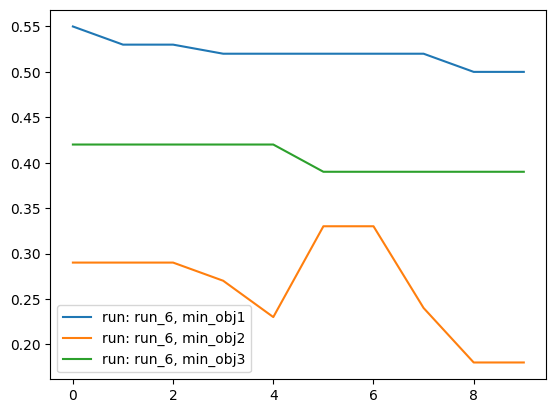

{0: {'min_obj1': 0.51, 'min_obj2': 0.4, 'min_obj3': 0.47, 'avg_obj1': 0.5942857142857143, 'avg_obj2': 0.4757142857142857, 'avg_obj3': 0.5671428571428572}, 1: {'min_obj1': 0.51, 'min_obj2': 0.36, 'min_obj3': 0.47, 'avg_obj1': 0.5963636363636363, 'avg_obj2': 0.4686363636363637, 'avg_obj3': 0.5613636363636364}, 2: {'min_obj1': 0.48, 'min_obj2': 0.33, 'min_obj3': 0.44, 'avg_obj1': 0.5846428571428571, 'avg_obj2': 0.46249999999999997, 'avg_obj3': 0.5753571428571428}, 3: {'min_obj1': 0.48, 'min_obj2': 0.33, 'min_obj3': 0.44, 'avg_obj1': 0.5760000000000001, 'avg_obj2': 0.444, 'avg_obj3': 0.6116}, 4: {'min_obj1': 0.43, 'min_obj2': 0.33, 'min_obj3': 0.39, 'avg_obj1': 0.5664285714285714, 'avg_obj2': 0.44857142857142857, 'avg_obj3': 0.6}, 5: {'min_obj1': 0.53, 'min_obj2': 0.13, 'min_obj3': 0.42, 'avg_obj1': 0.6736666666666667, 'avg_obj2': 0.36833333333333335, 'avg_obj3': 0.5763333333333333}, 6: {'min_obj1': 0.53, 'min_obj2': 0.13, 'min_obj3': 0.42, 'avg_obj1': 0.6613333333333333, 'avg_obj2': 0.372

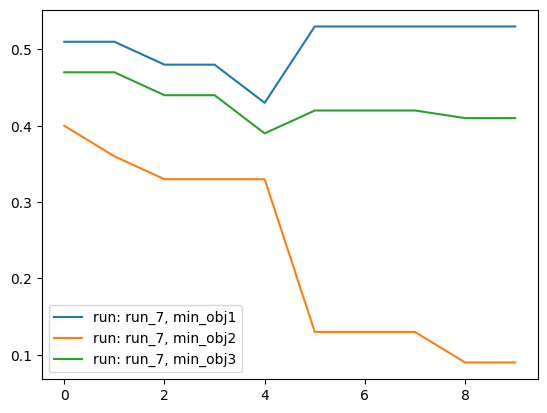

{0: {'min_obj1': 0.56, 'min_obj2': 0.49, 'min_obj3': 0.47, 'avg_obj1': 0.5964285714285714, 'avg_obj2': 0.5607142857142857, 'avg_obj3': 0.5357142857142857}, 1: {'min_obj1': 0.55, 'min_obj2': 0.46, 'min_obj3': 0.44, 'avg_obj1': 0.5933333333333334, 'avg_obj2': 0.5506666666666666, 'avg_obj3': 0.5473333333333332}, 2: {'min_obj1': 0.55, 'min_obj2': 0.42, 'min_obj3': 0.42, 'avg_obj1': 0.5953333333333333, 'avg_obj2': 0.56, 'avg_obj3': 0.5193333333333333}, 3: {'min_obj1': 0.53, 'min_obj2': 0.42, 'min_obj3': 0.42, 'avg_obj1': 0.583, 'avg_obj2': 0.5485, 'avg_obj3': 0.524}, 4: {'min_obj1': 0.53, 'min_obj2': 0.42, 'min_obj3': 0.42, 'avg_obj1': 0.5778260869565217, 'avg_obj2': 0.5391304347826087, 'avg_obj3': 0.5265217391304348}, 5: {'min_obj1': 0.51, 'min_obj2': 0.2, 'min_obj3': 0.4, 'avg_obj1': 0.656, 'avg_obj2': 0.45466666666666666, 'avg_obj3': 0.5313333333333333}, 6: {'min_obj1': 0.5, 'min_obj2': 0.2, 'min_obj3': 0.39, 'avg_obj1': 0.659, 'avg_obj2': 0.439, 'avg_obj3': 0.5453333333333333}, 7: {'min

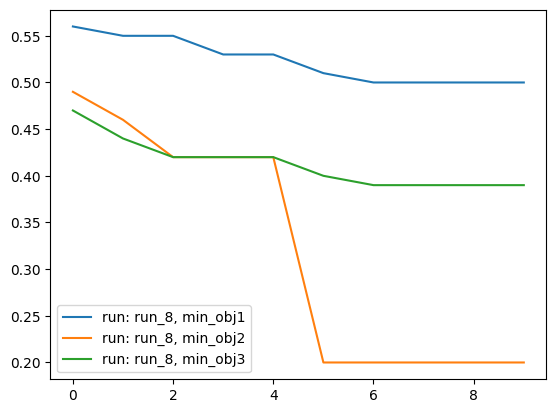

{0: {'min_obj1': 0.54, 'min_obj2': 0.39, 'min_obj3': 0.43, 'avg_obj1': 0.6146153846153847, 'avg_obj2': 0.5184615384615385, 'avg_obj3': 0.48000000000000004}, 1: {'min_obj1': 0.54, 'min_obj2': 0.38, 'min_obj3': 0.38, 'avg_obj1': 0.6073684210526316, 'avg_obj2': 0.5226315789473684, 'avg_obj3': 0.4757894736842105}, 2: {'min_obj1': 0.54, 'min_obj2': 0.36, 'min_obj3': 0.36, 'avg_obj1': 0.6107142857142858, 'avg_obj2': 0.47500000000000003, 'avg_obj3': 0.5042857142857142}, 3: {'min_obj1': 0.54, 'min_obj2': 0.32, 'min_obj3': 0.36, 'avg_obj1': 0.6111764705882353, 'avg_obj2': 0.46058823529411763, 'avg_obj3': 0.49}, 4: {'min_obj1': 0.53, 'min_obj2': 0.32, 'min_obj3': 0.36, 'avg_obj1': 0.6055555555555556, 'avg_obj2': 0.45333333333333337, 'avg_obj3': 0.48055555555555557}, 5: {'min_obj1': 0.46, 'min_obj2': 0.11, 'min_obj3': 0.42, 'avg_obj1': 0.5920000000000001, 'avg_obj2': 0.186, 'avg_obj3': 0.45733333333333337}, 6: {'min_obj1': 0.46, 'min_obj2': 0.08, 'min_obj3': 0.42, 'avg_obj1': 0.5933333333333333, 

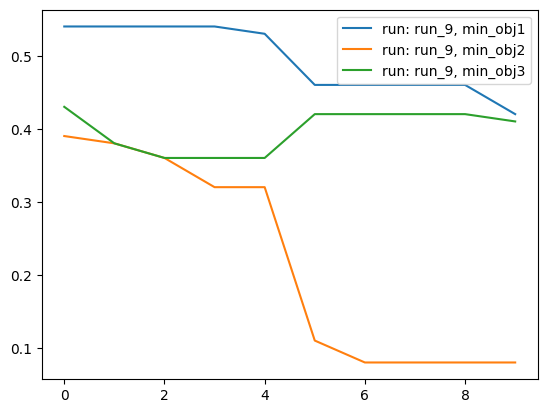

In [11]:
import matplotlib.pyplot as plt

def visualize(data_for_visualization: dict):
    for run, run_values in data_for_visualization.items():
        gens = []
        min_obj1_values = []
        min_obj2_values = []
        min_obj3_values = []
        print(run_values)
        for gen, gen_values in run_values.items():
            gens.append(gen)
            min_obj1 = gen_values["min_obj1"]
            min_obj2 = gen_values["min_obj2"]
            min_obj3 = gen_values["min_obj3"]

            min_obj1_values.append(min_obj1)
            min_obj2_values.append(min_obj2)
            min_obj3_values.append(min_obj3)

        plt.plot(gens, min_obj1_values, label=f"run: {run}, min_obj1")
        plt.plot(gens, min_obj2_values, label=f"run: {run}, min_obj2")
        plt.plot(gens, min_obj3_values, label=f"run: {run}, min_obj3")
        plt.legend()
        plt.show()

visualize(visualization_data)

{0: {'min_obj1': 0.49, 'min_obj2': 0.08, 'min_obj3': 0.69, 'avg_obj1': 0.555, 'avg_obj2': 0.19000000000000003, 'avg_obj3': 0.7583333333333333}, 1: {'min_obj1': 0.45, 'min_obj2': 0.08, 'min_obj3': 0.67, 'avg_obj1': 0.5328571428571428, 'avg_obj2': 0.1942857142857143, 'avg_obj3': 0.7585714285714287}, 2: {'min_obj1': 0.43, 'min_obj2': 0.08, 'min_obj3': 0.66, 'avg_obj1': 0.5528571428571428, 'avg_obj2': 0.17857142857142858, 'avg_obj3': 0.7514285714285714}, 3: {'min_obj1': 0.42, 'min_obj2': 0.08, 'min_obj3': 0.66, 'avg_obj1': 0.53875, 'avg_obj2': 0.17, 'avg_obj3': 0.760625}, 4: {'min_obj1': 0.4, 'min_obj2': 0.08, 'min_obj3': 0.66, 'avg_obj1': 0.5255555555555556, 'avg_obj2': 0.175, 'avg_obj3': 0.7616666666666667}, 5: {'min_obj1': 0.33, 'min_obj2': 0.1, 'min_obj3': 0.57, 'avg_obj1': 0.5157894736842106, 'avg_obj2': 0.23842105263157895, 'avg_obj3': 0.6947368421052631}, 6: {'min_obj1': 0.31, 'min_obj2': 0.1, 'min_obj3': 0.57, 'avg_obj1': 0.5171428571428571, 'avg_obj2': 0.22333333333333336, 'avg_ob

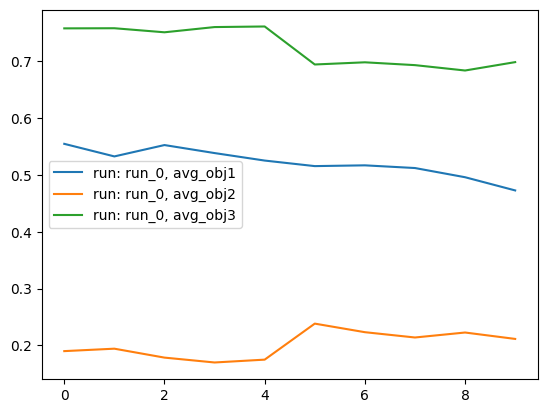

{0: {'min_obj1': 0.52, 'min_obj2': 0.25, 'min_obj3': 0.6, 'avg_obj1': 0.5641666666666667, 'avg_obj2': 0.345, 'avg_obj3': 0.7566666666666667}, 1: {'min_obj1': 0.48, 'min_obj2': 0.25, 'min_obj3': 0.6, 'avg_obj1': 0.5481818181818182, 'avg_obj2': 0.3181818181818182, 'avg_obj3': 0.7663636363636364}, 2: {'min_obj1': 0.46, 'min_obj2': 0.2, 'min_obj3': 0.59, 'avg_obj1': 0.5436842105263158, 'avg_obj2': 0.33, 'avg_obj3': 0.7273684210526316}, 3: {'min_obj1': 0.46, 'min_obj2': 0.2, 'min_obj3': 0.58, 'avg_obj1': 0.5499999999999999, 'avg_obj2': 0.3204166666666667, 'avg_obj3': 0.7229166666666668}, 4: {'min_obj1': 0.42, 'min_obj2': 0.2, 'min_obj3': 0.58, 'avg_obj1': 0.5579310344827586, 'avg_obj2': 0.3020689655172414, 'avg_obj3': 0.7241379310344828}, 5: {'min_obj1': 0.42, 'min_obj2': 0.25, 'min_obj3': 0.52, 'avg_obj1': 0.492, 'avg_obj2': 0.381, 'avg_obj3': 0.6295}, 6: {'min_obj1': 0.41, 'min_obj2': 0.24, 'min_obj3': 0.52, 'avg_obj1': 0.4932142857142857, 'avg_obj2': 0.3675, 'avg_obj3': 0.644642857142857

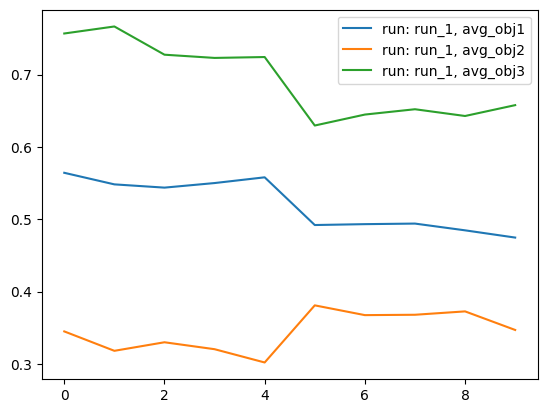

{0: {'min_obj1': 0.52, 'min_obj2': 0.3, 'min_obj3': 0.6, 'avg_obj1': 0.595, 'avg_obj2': 0.34299999999999997, 'avg_obj3': 0.71}, 1: {'min_obj1': 0.52, 'min_obj2': 0.26, 'min_obj3': 0.53, 'avg_obj1': 0.5881818181818181, 'avg_obj2': 0.3427272727272727, 'avg_obj3': 0.6763636363636363}, 2: {'min_obj1': 0.51, 'min_obj2': 0.26, 'min_obj3': 0.53, 'avg_obj1': 0.5833333333333334, 'avg_obj2': 0.335, 'avg_obj3': 0.7055555555555555}, 3: {'min_obj1': 0.5, 'min_obj2': 0.23, 'min_obj3': 0.53, 'avg_obj1': 0.59, 'avg_obj2': 0.3315384615384615, 'avg_obj3': 0.7138461538461538}, 4: {'min_obj1': 0.5, 'min_obj2': 0.23, 'min_obj3': 0.53, 'avg_obj1': 0.5756521739130435, 'avg_obj2': 0.34478260869565214, 'avg_obj3': 0.6726086956521738}, 5: {'min_obj1': 0.42, 'min_obj2': 0.25, 'min_obj3': 0.51, 'avg_obj1': 0.5313636363636364, 'avg_obj2': 0.41318181818181815, 'avg_obj3': 0.6168181818181818}, 6: {'min_obj1': 0.39, 'min_obj2': 0.25, 'min_obj3': 0.51, 'avg_obj1': 0.4988461538461539, 'avg_obj2': 0.40538461538461534, '

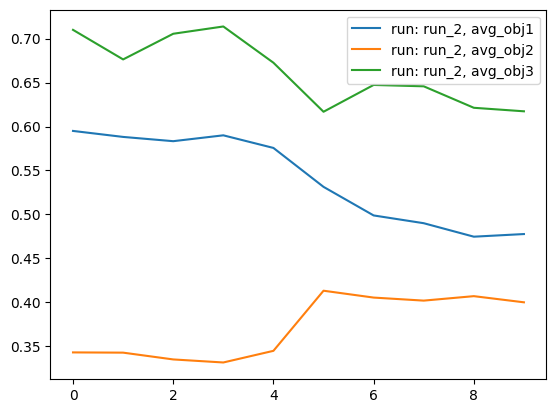

{0: {'min_obj1': 0.52, 'min_obj2': 0.37, 'min_obj3': 0.55, 'avg_obj1': 0.5854545454545454, 'avg_obj2': 0.41545454545454547, 'avg_obj3': 0.6218181818181818}, 1: {'min_obj1': 0.49, 'min_obj2': 0.34, 'min_obj3': 0.55, 'avg_obj1': 0.5786666666666667, 'avg_obj2': 0.41600000000000004, 'avg_obj3': 0.656}, 2: {'min_obj1': 0.45, 'min_obj2': 0.34, 'min_obj3': 0.52, 'avg_obj1': 0.5688888888888889, 'avg_obj2': 0.41444444444444445, 'avg_obj3': 0.6455555555555555}, 3: {'min_obj1': 0.45, 'min_obj2': 0.34, 'min_obj3': 0.52, 'avg_obj1': 0.5673684210526315, 'avg_obj2': 0.40842105263157896, 'avg_obj3': 0.6273684210526316}, 4: {'min_obj1': 0.43, 'min_obj2': 0.32, 'min_obj3': 0.52, 'avg_obj1': 0.5652380952380953, 'avg_obj2': 0.39809523809523806, 'avg_obj3': 0.6333333333333334}, 5: {'min_obj1': 0.46, 'min_obj2': 0.26, 'min_obj3': 0.49, 'avg_obj1': 0.5751724137931035, 'avg_obj2': 0.3903448275862069, 'avg_obj3': 0.5724137931034483}, 6: {'min_obj1': 0.44, 'min_obj2': 0.21, 'min_obj3': 0.49, 'avg_obj1': 0.56600

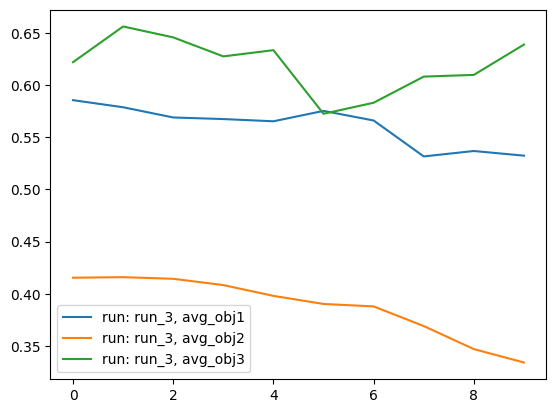

{0: {'min_obj1': 0.52, 'min_obj2': 0.17, 'min_obj3': 0.55, 'avg_obj1': 0.6025, 'avg_obj2': 0.33, 'avg_obj3': 0.63}, 1: {'min_obj1': 0.5, 'min_obj2': 0.17, 'min_obj3': 0.55, 'avg_obj1': 0.59, 'avg_obj2': 0.31272727272727274, 'avg_obj3': 0.6790909090909091}, 2: {'min_obj1': 0.5, 'min_obj2': 0.17, 'min_obj3': 0.52, 'avg_obj1': 0.5933333333333334, 'avg_obj2': 0.3253333333333333, 'avg_obj3': 0.6726666666666666}, 3: {'min_obj1': 0.49, 'min_obj2': 0.17, 'min_obj3': 0.5, 'avg_obj1': 0.5583333333333333, 'avg_obj2': 0.32916666666666666, 'avg_obj3': 0.6491666666666667}, 4: {'min_obj1': 0.49, 'min_obj2': 0.17, 'min_obj3': 0.5, 'avg_obj1': 0.556875, 'avg_obj2': 0.315625, 'avg_obj3': 0.64375}, 5: {'min_obj1': 0.55, 'min_obj2': 0.16, 'min_obj3': 0.44, 'avg_obj1': 0.6121428571428572, 'avg_obj2': 0.28928571428571426, 'avg_obj3': 0.5375}, 6: {'min_obj1': 0.55, 'min_obj2': 0.14, 'min_obj3': 0.44, 'avg_obj1': 0.6123333333333334, 'avg_obj2': 0.2803333333333333, 'avg_obj3': 0.5396666666666667}, 7: {'min_obj

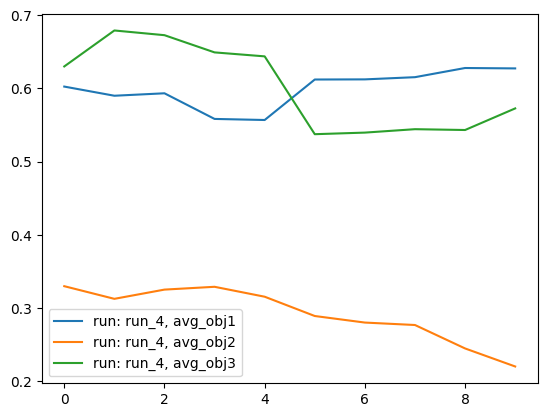

{0: {'min_obj1': 0.49, 'min_obj2': 0.44, 'min_obj3': 0.51, 'avg_obj1': 0.5922222222222222, 'avg_obj2': 0.5144444444444445, 'avg_obj3': 0.5644444444444444}, 1: {'min_obj1': 0.46, 'min_obj2': 0.37, 'min_obj3': 0.49, 'avg_obj1': 0.5823076923076923, 'avg_obj2': 0.5184615384615385, 'avg_obj3': 0.5700000000000001}, 2: {'min_obj1': 0.45, 'min_obj2': 0.37, 'min_obj3': 0.45, 'avg_obj1': 0.5725, 'avg_obj2': 0.5189999999999999, 'avg_obj3': 0.5635}, 3: {'min_obj1': 0.45, 'min_obj2': 0.37, 'min_obj3': 0.45, 'avg_obj1': 0.5789473684210527, 'avg_obj2': 0.5026315789473684, 'avg_obj3': 0.5615789473684211}, 4: {'min_obj1': 0.45, 'min_obj2': 0.33, 'min_obj3': 0.45, 'avg_obj1': 0.5778260869565218, 'avg_obj2': 0.4991304347826087, 'avg_obj3': 0.5930434782608696}, 5: {'min_obj1': 0.44, 'min_obj2': 0.11, 'min_obj3': 0.48, 'avg_obj1': 0.5666666666666667, 'avg_obj2': 0.24125, 'avg_obj3': 0.5541666666666667}, 6: {'min_obj1': 0.42, 'min_obj2': 0.11, 'min_obj3': 0.48, 'avg_obj1': 0.5499999999999999, 'avg_obj2': 0.

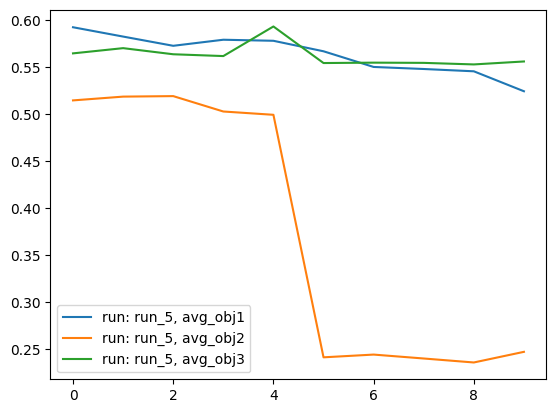

{0: {'min_obj1': 0.55, 'min_obj2': 0.29, 'min_obj3': 0.42, 'avg_obj1': 0.5933333333333334, 'avg_obj2': 0.35833333333333334, 'avg_obj3': 0.535}, 1: {'min_obj1': 0.53, 'min_obj2': 0.29, 'min_obj3': 0.42, 'avg_obj1': 0.5733333333333334, 'avg_obj2': 0.3666666666666667, 'avg_obj3': 0.5783333333333334}, 2: {'min_obj1': 0.53, 'min_obj2': 0.29, 'min_obj3': 0.42, 'avg_obj1': 0.5763636363636363, 'avg_obj2': 0.3836363636363636, 'avg_obj3': 0.6109090909090908}, 3: {'min_obj1': 0.52, 'min_obj2': 0.27, 'min_obj3': 0.42, 'avg_obj1': 0.5786666666666667, 'avg_obj2': 0.3453333333333333, 'avg_obj3': 0.622}, 4: {'min_obj1': 0.52, 'min_obj2': 0.23, 'min_obj3': 0.42, 'avg_obj1': 0.5777777777777778, 'avg_obj2': 0.33055555555555555, 'avg_obj3': 0.6211111111111111}, 5: {'min_obj1': 0.52, 'min_obj2': 0.33, 'min_obj3': 0.39, 'avg_obj1': 0.6010714285714285, 'avg_obj2': 0.4525, 'avg_obj3': 0.5146428571428572}, 6: {'min_obj1': 0.52, 'min_obj2': 0.33, 'min_obj3': 0.39, 'avg_obj1': 0.6108333333333333, 'avg_obj2': 0.4

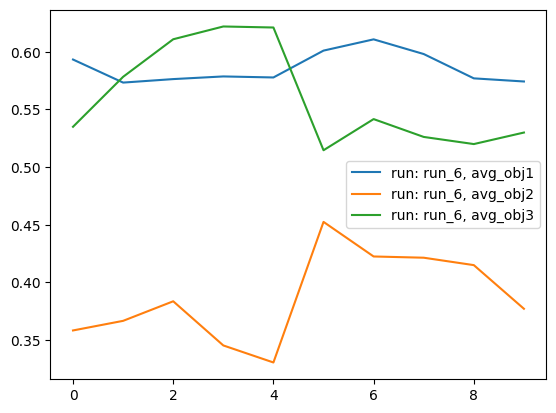

{0: {'min_obj1': 0.51, 'min_obj2': 0.4, 'min_obj3': 0.47, 'avg_obj1': 0.5942857142857143, 'avg_obj2': 0.4757142857142857, 'avg_obj3': 0.5671428571428572}, 1: {'min_obj1': 0.51, 'min_obj2': 0.36, 'min_obj3': 0.47, 'avg_obj1': 0.5963636363636363, 'avg_obj2': 0.4686363636363637, 'avg_obj3': 0.5613636363636364}, 2: {'min_obj1': 0.48, 'min_obj2': 0.33, 'min_obj3': 0.44, 'avg_obj1': 0.5846428571428571, 'avg_obj2': 0.46249999999999997, 'avg_obj3': 0.5753571428571428}, 3: {'min_obj1': 0.48, 'min_obj2': 0.33, 'min_obj3': 0.44, 'avg_obj1': 0.5760000000000001, 'avg_obj2': 0.444, 'avg_obj3': 0.6116}, 4: {'min_obj1': 0.43, 'min_obj2': 0.33, 'min_obj3': 0.39, 'avg_obj1': 0.5664285714285714, 'avg_obj2': 0.44857142857142857, 'avg_obj3': 0.6}, 5: {'min_obj1': 0.53, 'min_obj2': 0.13, 'min_obj3': 0.42, 'avg_obj1': 0.6736666666666667, 'avg_obj2': 0.36833333333333335, 'avg_obj3': 0.5763333333333333}, 6: {'min_obj1': 0.53, 'min_obj2': 0.13, 'min_obj3': 0.42, 'avg_obj1': 0.6613333333333333, 'avg_obj2': 0.372

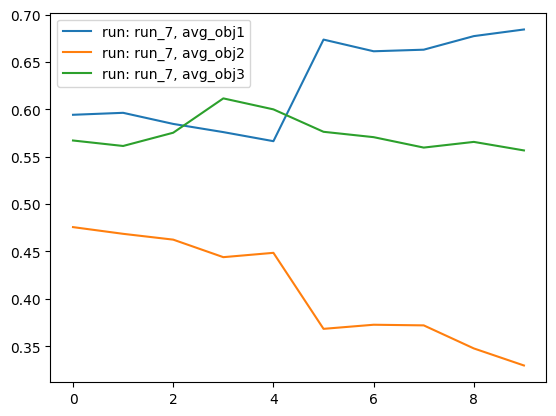

{0: {'min_obj1': 0.56, 'min_obj2': 0.49, 'min_obj3': 0.47, 'avg_obj1': 0.5964285714285714, 'avg_obj2': 0.5607142857142857, 'avg_obj3': 0.5357142857142857}, 1: {'min_obj1': 0.55, 'min_obj2': 0.46, 'min_obj3': 0.44, 'avg_obj1': 0.5933333333333334, 'avg_obj2': 0.5506666666666666, 'avg_obj3': 0.5473333333333332}, 2: {'min_obj1': 0.55, 'min_obj2': 0.42, 'min_obj3': 0.42, 'avg_obj1': 0.5953333333333333, 'avg_obj2': 0.56, 'avg_obj3': 0.5193333333333333}, 3: {'min_obj1': 0.53, 'min_obj2': 0.42, 'min_obj3': 0.42, 'avg_obj1': 0.583, 'avg_obj2': 0.5485, 'avg_obj3': 0.524}, 4: {'min_obj1': 0.53, 'min_obj2': 0.42, 'min_obj3': 0.42, 'avg_obj1': 0.5778260869565217, 'avg_obj2': 0.5391304347826087, 'avg_obj3': 0.5265217391304348}, 5: {'min_obj1': 0.51, 'min_obj2': 0.2, 'min_obj3': 0.4, 'avg_obj1': 0.656, 'avg_obj2': 0.45466666666666666, 'avg_obj3': 0.5313333333333333}, 6: {'min_obj1': 0.5, 'min_obj2': 0.2, 'min_obj3': 0.39, 'avg_obj1': 0.659, 'avg_obj2': 0.439, 'avg_obj3': 0.5453333333333333}, 7: {'min

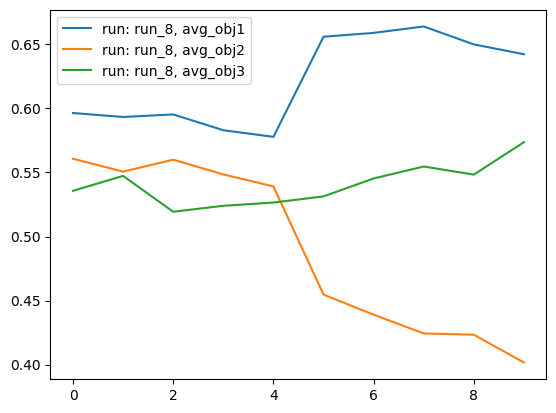

{0: {'min_obj1': 0.54, 'min_obj2': 0.39, 'min_obj3': 0.43, 'avg_obj1': 0.6146153846153847, 'avg_obj2': 0.5184615384615385, 'avg_obj3': 0.48000000000000004}, 1: {'min_obj1': 0.54, 'min_obj2': 0.38, 'min_obj3': 0.38, 'avg_obj1': 0.6073684210526316, 'avg_obj2': 0.5226315789473684, 'avg_obj3': 0.4757894736842105}, 2: {'min_obj1': 0.54, 'min_obj2': 0.36, 'min_obj3': 0.36, 'avg_obj1': 0.6107142857142858, 'avg_obj2': 0.47500000000000003, 'avg_obj3': 0.5042857142857142}, 3: {'min_obj1': 0.54, 'min_obj2': 0.32, 'min_obj3': 0.36, 'avg_obj1': 0.6111764705882353, 'avg_obj2': 0.46058823529411763, 'avg_obj3': 0.49}, 4: {'min_obj1': 0.53, 'min_obj2': 0.32, 'min_obj3': 0.36, 'avg_obj1': 0.6055555555555556, 'avg_obj2': 0.45333333333333337, 'avg_obj3': 0.48055555555555557}, 5: {'min_obj1': 0.46, 'min_obj2': 0.11, 'min_obj3': 0.42, 'avg_obj1': 0.5920000000000001, 'avg_obj2': 0.186, 'avg_obj3': 0.45733333333333337}, 6: {'min_obj1': 0.46, 'min_obj2': 0.08, 'min_obj3': 0.42, 'avg_obj1': 0.5933333333333333, 

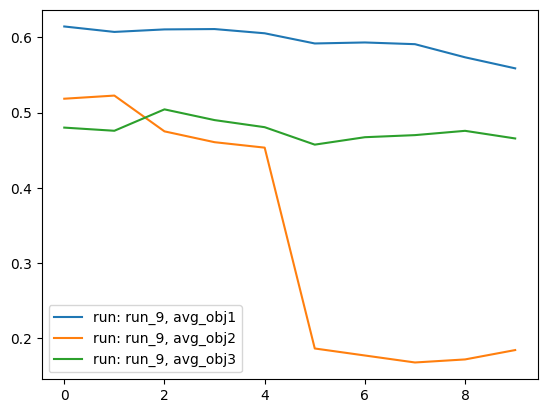

In [12]:
import matplotlib.pyplot as plt

def visualize(data_for_visualization: dict):
    for run, run_values in data_for_visualization.items():
        gens = []
        avg_obj1_values = []
        avg_obj2_values = []
        avg_obj3_values = []
        print(run_values)
        for gen, gen_values in run_values.items():
            gens.append(gen)
            avg_obj1 = gen_values["avg_obj1"]
            avg_obj2 = gen_values["avg_obj2"]
            avg_obj3 = gen_values["avg_obj3"]

            avg_obj1_values.append(avg_obj1)
            avg_obj2_values.append(avg_obj2)
            avg_obj3_values.append(avg_obj3)

        plt.plot(gens, avg_obj1_values, label=f"run: {run}, avg_obj1")
        plt.plot(gens, avg_obj2_values, label=f"run: {run}, avg_obj2")
        plt.plot(gens, avg_obj3_values, label=f"run: {run}, avg_obj3")
        plt.legend()
        plt.show()

visualize(visualization_data)